# Lab 1: Iris Data Exploration and Visualization

This lab is an open-ended exploration of the Iris dataset . There is no single required sequence of analyses and no need to complete every section.

## Setup

Run these cells to import the packages and load the dataset.

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

In [20]:
iris = pd.read_csv("data/iris.csv")
iris.head(10)

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


## 1. Become familiar with the dataset

Explore the structure and contents of the dataset.

Consider:

- What does one row represent?
- What does each column represent?
- Which attributes are numeric and which are categorical?
- How large is the dataset?
- Are any values missing?
- How many observations belong to each species?

In [21]:
import pandas as pd

df = pd.read_csv("data/iris.csv")
print(df.shape)   # e.g. (150, 5)
print(df.shape[0])  # 150
print(df.shape[1])  # 5

(150, 5)
150
5


In [22]:
#si pongo 2 funciones en un box, se ejecutan ambas, pero solo se muestra el resultado 
# de la última función. Para mostrar el resultado de ambas funciones, 
# puedo usar print() para la primera función. 
iris.columns
iris.dtypes

sepal_length_cm    float64
sepal_width_cm     float64
petal_length_cm    float64
petal_width_cm     float64
species                str
dtype: object

In [23]:
iris.isna().sum()

sepal_length_cm    0
sepal_width_cm     0
petal_length_cm    0
petal_width_cm     0
species            0
dtype: int64

In [24]:
iris["species"].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [25]:
iris.describe() 

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## 2. Develop questions about the data

Write down questions that you could investigate.

Possible starting points:

- What are typical sepal and petal measurements for each species?
- Are there any possible outliers?
- Which attributes are related?
- Which attributes appear most useful for distinguishing species?
- What else would you like to learn from the data?

**Your questions:**

1. wich of the species has the longer mean lengh of the petal
2. Does petal lengh differ significantly among species?
3. Are there any outlier sepal lenght? 
4. Wich of he petal width has the higher SD

## 3. Explore individual attributes

Investigate one or more attributes on their own.

Consider typical values, variability, the shape of the distribution, possible unusual observations, and whether the results change when the species are considered separately.

count    150.000000
mean       5.843333
std        0.828066
min        4.300000
25%        5.100000
50%        5.800000
75%        6.400000
max        7.900000
Name: sepal_length_cm, dtype: float64


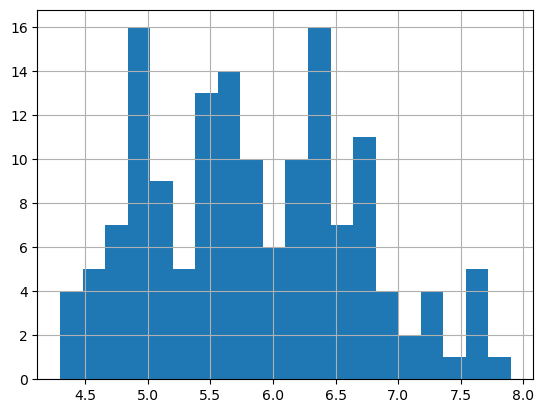

In [26]:
df = pd.read_csv("data/iris.csv")
print(df["sepal_length_cm"].describe())

df["sepal_length_cm"].hist(bins=20)
plt.show()

count    150.000000
mean       3.758000
std        1.765298
min        1.000000
25%        1.600000
50%        4.350000
75%        5.100000
max        6.900000
Name: petal_length_cm, dtype: float64


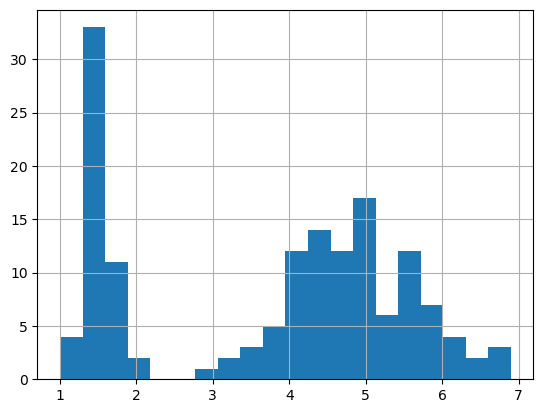

In [39]:
df = pd.read_csv("data/iris.csv")
print(df["petal_length_cm"].describe())

df["petal_length_cm"].hist(bins=20)
plt.show()

count    150.000000
mean       3.057333
std        0.435866
min        2.000000
25%        2.800000
50%        3.000000
75%        3.300000
max        4.400000
Name: sepal_width_cm, dtype: float64


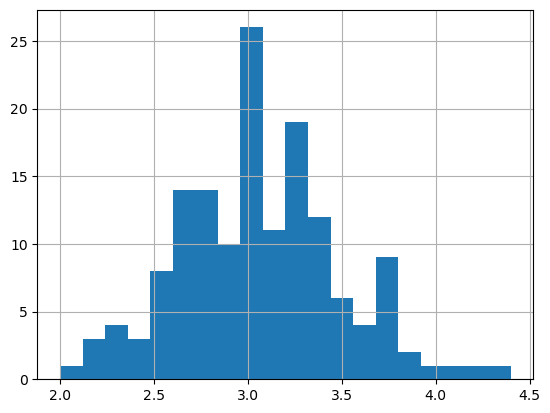

In [27]:
df = pd.read_csv("data/iris.csv")
print(df["sepal_width_cm"].describe())

df["sepal_width_cm"].hist(bins=20)
plt.show()

/var/folders/bd/rn69n1b56x777p4_l1wx55s40000gn/T/ipykernel_5818/1066547841.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=iris["species"].unique())


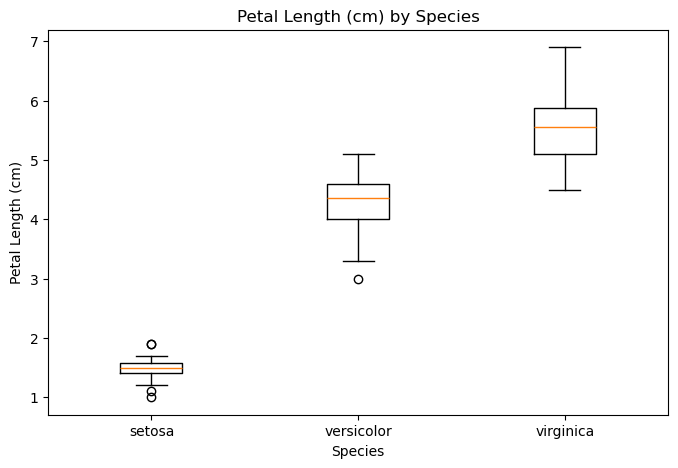

In [30]:

##outliers se ven con boxplot. normalmente se ppone el Q1 y Q3 pero tb se puede cambiar
import pandas as pd
import matplotlib.pyplot as plt

iris = pd.read_csv("data/iris.csv")

data = [iris.loc[iris["species"] == s, "petal_length_cm"] for s in iris["species"].unique()]

plt.figure(figsize=(8, 5))
plt.boxplot(data, labels=iris["species"].unique())
plt.title("Petal Length (cm) by Species")
plt.ylabel("Petal Length (cm)")
plt.xlabel("Species")
plt.show()
z

## 4. Explore relationships between attributes

Investigate relationships between two or more numeric attributes.

Consider whether measurements increase together, whether the species form visible groups, whether relationships look different for different species, and whether some pairs of attributes are more useful than others.

In [33]:
pip install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 16.2 MB/s  0:00:01m0:00:0100:01
Note: you may need to restart the kernel to use updated packages.


In [ ]:
#Does petal lengh differ significantly among species?
import pandas as pd
from scipy import stats

iris = pd.read_csv("data/iris.csv")

# medias por especie
print(iris.groupby("species")["petal_length_cm"].mean())

# ANOVA de una vía
setosa = iris.loc[iris["species"] == "setosa", "petal_length_cm"]
versicolor = iris.loc[iris["species"] == "versicolor", "petal_length_cm"]
virginica = iris.loc[iris["species"] == "virginica", "petal_length_cm"]

f_stat, p_value = stats.f_oneway(setosa, versicolor, virginica)
print("ANOVA F =", f_stat)
print("p-value =", p_value)

SyntaxError: unterminated string literal (detected at line 21) (382830019.py, line 21)

## 5. Compare the species

Explore how the measurements differ among the three Iris species.

Consider:

- Which measurements differ most visibly by species?
- Which species appear easiest or hardest to distinguish?
- Where is there substantial overlap?
- Which summaries or visualizations help answer these questions?

                 sepal_length_cm  sepal_width_cm  petal_length_cm  \
sepal_length_cm         1.000000       -0.117570         0.871754   
sepal_width_cm         -0.117570        1.000000        -0.428440   
petal_length_cm         0.871754       -0.428440         1.000000   
petal_width_cm          0.817941       -0.366126         0.962865   

                 petal_width_cm  
sepal_length_cm        0.817941  
sepal_width_cm        -0.366126  
petal_length_cm        0.962865  
petal_width_cm         1.000000  


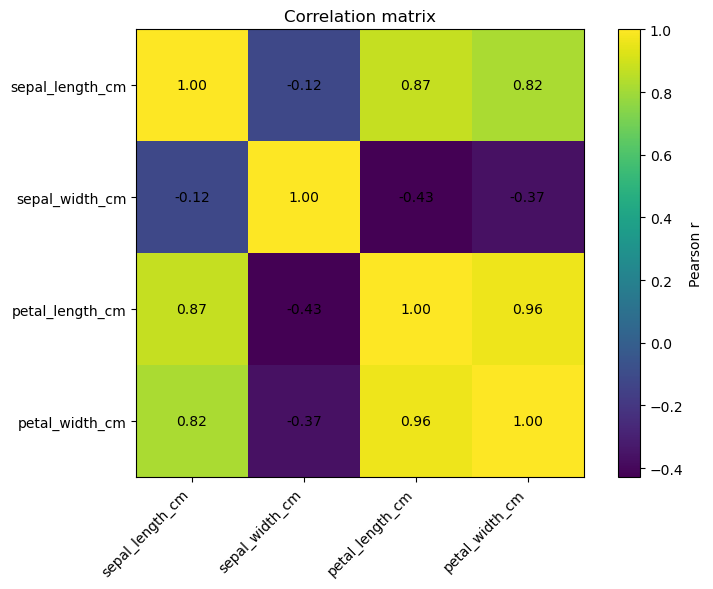

In [42]:
#aprender a hacer correlation matrix 

import pandas as pd
import matplotlib.pyplot as plt

iris = pd.read_csv("data/iris.csv")

corr = iris.select_dtypes(include="number").corr(method="pearson")
print(corr)

plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap="viridis", interpolation="nearest")
plt.colorbar(label="Pearson r")
plt.xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr)), corr.index)
for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black")
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

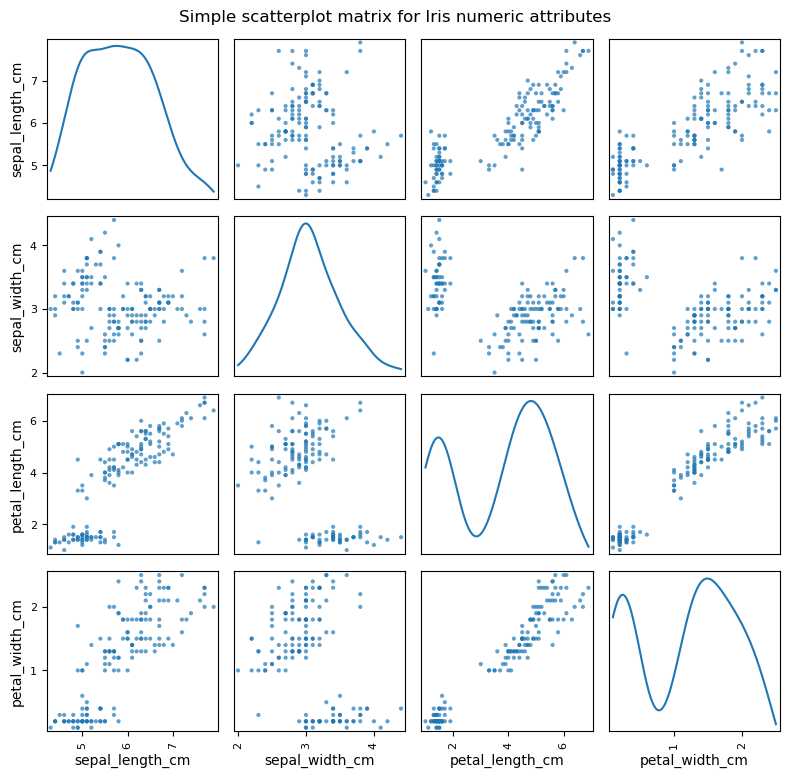

In [38]:
#aprender a hacer simple scatterplot matrix
from pandas.plotting import scatter_matrix

iris = pd.read_csv("data/iris.csv")

numeric_cols = iris.select_dtypes(include="number").columns
scatter_matrix(iris[numeric_cols], alpha=0.7, figsize=(8, 8), diagonal="kde")
plt.suptitle("Simple scatterplot matrix for Iris numeric attributes")
plt.tight_layout()
plt.show()

## 6. Choose useful visualizations

Try visualizations that match the questions you are asking.

Possibilities include histograms, boxplots, scatterplots, bar charts, or a visualization of the correlation matrix.

Think about what each visualization reveals and what it may hide.

## 7. Identify informative attributes

Which attribute, or combination of attributes, appears most useful for distinguishing the Iris species?

Support your answer with evidence from your analysis.

**Your conclusion:**

## 8. Continue your own investigation

Use the remaining space to investigate any new questions that arose while exploring the data.